In [91]:
'''
prompt:
Escreva codigo python que le todos os arquivos CSV disponiveis na pasta data/model-runs. 
O nome de cada arquivo CSV está no formato gemini-2.5-flash_answers.csv, em que tudo que vem antes de  "_answers.csv" é o nome do modelo. 

Leia cada arquivo CSV com o pandas. 
Cada linha do arquivo é uma questão da OAB que o modelo resolveu. 
Calcule o número de respostas certas comparando se "alternativa" == "correct". 
Crie um df em que cada row é um modelo, com a nota total e a nota percentual.

'''

import pandas as pd
import os
import glob
import re

# Caminho da pasta com os arquivos CSV
folder_path = '../data/processed/model-runs/'
csv_files = glob.glob(os.path.join(folder_path, '*_answers_irac*.csv'))

# Lista para guardar os resultados de cada modelo
model_results = []

for filepath in csv_files:
    # Extrai o nome do modelo a partir do nome do arquivo
    filename = os.path.basename(filepath)
    match = re.match(r'(.+)_answers_irac-(.*)\.csv$', filename)
    if match:
        model_name = match.group(1)
        irac = match.group(2)


    # Lê o CSV com pandas
    df = pd.read_csv(filepath)

    # Garante que as colunas esperadas estão presentes
    if 'alternativa' not in df.columns or 'correct' not in df.columns:
        print(f"Aviso: arquivo {filename} não contém as colunas esperadas.")
        continue

    # Conta quantas respostas estão corretas
    total_questions = len(df)
    correct_answers = (df['alternativa'] == df['correct']).sum()
    percentage = correct_answers / total_questions * 100

    # Adiciona os resultados à lista
    model_results.append({
        'modelo': model_name,
        'irac': irac,
        'questões': total_questions,
        'acertos': correct_answers,
        'percentual': round(percentage, 2)
    })

# Cria um DataFrame com os resultados
results_df = pd.DataFrame(model_results)

# Ordena do maior para o menor percentual de acertos
results_df = results_df.sort_values(by=['modelo', 'percentual'], ascending=False)

results_df.head(300)


,modelo,irac,questões,acertos,percentual
38,gemini-2.5-pro,_R__,15,15,100.00
39,gemini-2.5-pro,__A_,25,25,100.00
40,gemini-2.5-pro,___C,25,25,100.00
37,gemini-2.5-pro,I___,40,38,95.00
41,gemini-2.5-pro,____,115,108,93.91
36,gemini-2.5-pro,IR__,10,9,90.00
27,gemini-2.5-flash-lite-preview-06-17,__A_,150,145,96.67
28,gemini-2.5-flash-lite-preview-06-17,___C,125,120,96.00
24,gemini-2.5-flash-lite-preview-06-17,IR__,145,105,72.41
25,gemini-2.5-flash-lite-preview-06-17,I___,200,140,70.00


In [92]:
import pandas as pd
import os
import glob
import re
import json

# Caminho da pasta com os arquivos CSV
folder_path = '../data/processed/model-runs/'
csv_files = glob.glob(os.path.join(folder_path, '*_answers_irac*.csv'))

# Lista para guardar todos os dados juntos
all_data = []

for filepath in csv_files:
    # Extrai o nome do modelo a partir do nome do arquivo
    filename = os.path.basename(filepath)
    match = re.match(r'(.+)_answers_irac-(.*)\.csv$', filename)
    if match:
        model_name = match.group(1)
        irac = match.group(2)

    # Lê o CSV com pandas
    df = pd.read_csv(filepath)

    # Garante que as colunas esperadas estão presentes
    if not {'alternativa', 'correct', 'question_id'}.issubset(df.columns):
        print(f"Aviso: arquivo {filename} não contém as colunas esperadas.")
        continue

    # Adiciona colunas de metadados
    df['modelo'] = model_name
    df['irac'] = irac
    df['acertou'] = df['alternativa'] == df['correct']


    # Armazena os dados
    all_data.append(df)

# Junta todos os dados em um único DataFrame
full_df = pd.concat(all_data, ignore_index=True)

full_df.head()

,pdf_filename,materia,prova,questao,question_id,enunciado,A,B,C,D,resposta_completa,alternativa,correct,prompt,irac,rule_count,modelo,acertou
0,oab-99.pdf,DIREITO TRIBUTÁRIO,II,9,oab-99.pdf-009,"Pizza Aqui Ltda., empresa do ramo dos restaura...",a Pizza Aqui responde solidariamente pelos tri...,caso a Pizza Já prossiga na exploração da mesm...,caso a Pizza Já mude de ramo de comércio dentr...,"caso o negócio jurídico não fosse a aquisição,...",resposta: A\n,A,B,Resolva a questão do exame da ordem da OAB aba...,IR__,3.0,gemini-1.5-flash-8b,False
1,oab-182.pdf,ECA,XIII,6,oab-182.pdf-006,"ADOLESCENTE\nVilma, avó materna do menor Oscar...","Do ponto de vista processual, Vilma não tem le...","Do ponto de vista material, os elementos indic...","Do ponto de vista material, os argumentos indi...","Do ponto de vista processual, Vilma possui leg...",resposta: A\n,A,D,Resolva a questão do exame da ordem da OAB aba...,IR__,5.0,gemini-1.5-flash-8b,False
2,oab-315.pdf,DIREITO DO TRABALHO,XXXI,186,oab-315.pdf-186,Enzo é professor de Matemática em uma escola p...,O casal poderá faltar aos seus empregos respec...,"Carla, por ser advogada, terá afastamento de 5...","Enzo poderá faltar ao serviço por 9 dias, enqu...","Não há previsão específica, devendo ser acerta...",resposta: D\n,D,C,Resolva a questão do exame da ordem da OAB aba...,IR__,2.0,gemini-1.5-flash-8b,False
3,oab-319.pdf,DIREITO DO TRABALHO,XXXVIII,227,oab-319.pdf-227,Sílvio Luiz foi convidado pelo seu empregador ...,Caso não haja a vacância e cessada a interinid...,"Sílvio Luiz, no caso de vacância definitiva do...",Sendo a hipótese de férias do efetivo supervis...,Considerando que o exercício do cargo será int...,resposta: D\n,D,D,Resolva a questão do exame da ordem da OAB aba...,IR__,0.0,gemini-1.5-flash-8b,True
4,oab-119.pdf,DIREITO ADMINISTRATIVO,IX,3,oab-119.pdf-003,A desapropriação é um procedimento administrat...,Gera o direito à imissão provisória na posse e...,Acarreta a aquisição da propriedade pela Admin...,Importa no início do prazo para a ocorrência d...,"Implica a geração de efeitos, com o titular ma...",resposta: C\n,C,C,Resolva a questão do exame da ordem da OAB aba...,IR__,4.0,gemini-1.5-flash-8b,True


In [93]:
full_df.columns

Index(['pdf_filename', 'materia', 'prova', 'questao', 'question_id',
       'enunciado', 'A', 'B', 'C', 'D', 'resposta_completa', 'alternativa',
       'correct', 'prompt', 'irac', 'rule_count', 'modelo', 'acertou'],
      dtype='object')

In [94]:
# Calcula a acurácia e média de rule_count por question_id e materia
accuracy_by_question_df = (
    full_df.groupby(['question_id', 'materia'])
    .agg(acurácia=('acertou', 'mean'),
         rule_count=('rule_count', 'mean'))
    .reset_index()
    .sort_values(by='acurácia', ascending=False)
)

# Exibe as 100 últimas linhas (menor acurácia)
accuracy_by_question_df.tail(100)


,question_id,materia,acurácia,rule_count
63,oab-190.pdf-083,ECA,0.866667,6.0
108,oab-263.pdf-178,DIREITO PENAL,0.857143,3.0
66,oab-194.pdf-039,DIREITO DO CONSUMIDOR,0.857143,7.0
75,oab-20.pdf-196,ÉTICA PROFISSIONAL,0.850000,4.0
149,oab-336.pdf-149,PROCESSO DO TRABALHO,0.846154,4.0
...,...,...,...,...
104,oab-257.pdf-114,DIREITO PENAL,0.111111,4.0
71,oab-198.pdf-001,DIREITO EMPRESARIAL,0.100000,4.0
145,oab-327.pdf-054,PROCESSO DO TRABALHO,0.000000,7.0
94,oab-242.pdf-239,PROCESSO CIVIL,0.000000,2.0


In [95]:

# Contagem e porcentagem de alternativas por questão
counts = full_df.groupby(['question_id', 'alternativa']).size().reset_index(name='count')
total_per_question = counts.groupby('question_id')['count'].transform('sum')
counts['percentage'] = (counts['count'] / total_per_question) * 100

# Pivot com alternativas como colunas
percentage_df = counts.pivot(index='question_id', columns='alternativa', values='percentage').fillna(0)

# Adiciona coluna 'correct'
correct_values = full_df.groupby('question_id')['correct'].first()
percentage_df = percentage_df.merge(correct_values, on='question_id').reset_index()


percentage_df.head()

,question_id,A,B,C,D,correct
0,oab-1.pdf-003,0.000000,5.555556,27.777778,66.666667,D
1,oab-100.pdf-014,3.225806,3.225806,0.000000,93.548387,D
2,oab-100.pdf-019,0.000000,0.000000,11.764706,88.235294,D
3,oab-103.pdf-048,0.000000,0.000000,0.000000,100.000000,D
4,oab-104.pdf-055,92.857143,7.142857,0.000000,0.000000,A


In [96]:
analysis_df = percentage_df.merge(accuracy_by_question_df, on='question_id', how='inner')
analysis_df = analysis_df.sort_values(by='acurácia', ascending=False)

analysis_df

,question_id,A,B,C,D,correct,materia,acurácia,rule_count
49,oab-17.pdf-162,0.000000,100.000000,0.000000,0.000000,B,ÉTICA PROFISSIONAL,1.000000,1.0
132,oab-303.pdf-063,0.000000,100.000000,0.000000,0.000000,B,DIREITO DO TRABALHO,1.000000,4.0
115,oab-274.pdf-030,0.000000,0.000000,100.000000,0.000000,C,PROCESSO PENAL,1.000000,7.0
81,oab-206.pdf-081,0.000000,0.000000,100.000000,0.000000,C,DIREITO EMPRESARIAL,1.000000,3.0
157,oab-38.pdf-376,0.000000,0.000000,100.000000,0.000000,C,ÉTICA PROFISSIONAL,1.000000,1.0
...,...,...,...,...,...,...,...,...,...
104,oab-257.pdf-114,22.222222,66.666667,0.000000,11.111111,D,DIREITO PENAL,0.111111,4.0
71,oab-198.pdf-001,0.000000,77.777778,11.111111,11.111111,C,DIREITO EMPRESARIAL,0.100000,4.0
145,oab-327.pdf-054,0.000000,100.000000,0.000000,0.000000,A,PROCESSO DO TRABALHO,0.000000,7.0
94,oab-242.pdf-239,40.000000,0.000000,40.000000,20.000000,B,PROCESSO CIVIL,0.000000,2.0


<Figure size 1000x600 with 0 Axes>

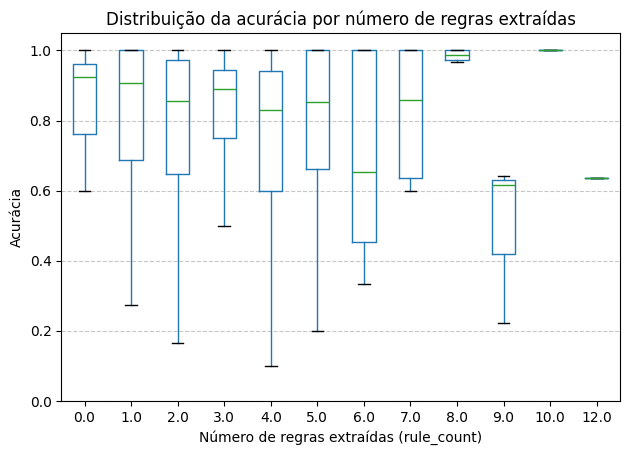

In [97]:
import matplotlib.pyplot as plt

# Plot de boxplot diretamente a partir do DataFrame original
plt.figure(figsize=(10, 6))
accuracy_by_question_df.boxplot(
    column='acurácia',
    by='rule_count',
    grid=False,
    showfliers=False  # oculta outliers, opcional
)

plt.xlabel('Número de regras extraídas (rule_count)')
plt.ylabel('Acurácia')
plt.title('Distribuição da acurácia por número de regras extraídas')
plt.suptitle('')  # Remove o título automático extra do pandas
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


<Figure size 1000x600 with 0 Axes>

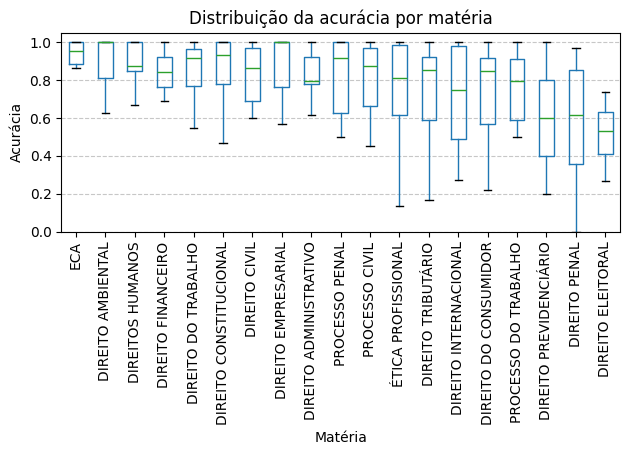

In [98]:
import matplotlib.pyplot as plt
import pandas as pd

# Calcula a ordem das matérias pela média da acurácia (maior para menor)
materia_order = (
    accuracy_by_question_df.groupby('materia')['acurácia']
    .mean()
    .sort_values(ascending=False)
    .index
)

# Reordena o DataFrame conforme essa ordem
accuracy_sorted_df = accuracy_by_question_df.copy()
accuracy_sorted_df['materia'] = pd.Categorical(
    accuracy_sorted_df['materia'],
    categories=materia_order,
    ordered=True
)

# Plot do boxplot
plt.figure(figsize=(10, 6))
accuracy_sorted_df.boxplot(
    column='acurácia',
    by='materia',
    grid=False,
    showfliers=False  # oculta outliers
)

plt.xlabel('Matéria')
plt.ylabel('Acurácia')
plt.title('Distribuição da acurácia por matéria')
plt.suptitle('')  # Remove título automático extra do pandas
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Gira os labels do eixo X para vertical
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()


In [99]:
import pandas as pd

# Função para calcular DI de uma questão
def discrimination_index(df, top_pct=0.15):
    di_list = []

    # Calcula a pontuação total de cada aluno (soma de acertos)
    df['total_acertos'] = df.groupby('pdf_filename')['acertou'].transform('sum')

    # Para cada questão
    for qid, group in df.groupby('question_id'):
        # Ordena alunos pelo total de acertos
        group_sorted = group.sort_values('total_acertos', ascending=False)
        n = len(group_sorted)
        n_top = max(1, int(top_pct * n))   # garante pelo menos 1 aluno
        n_bottom = n_top

        # Divide em top e bottom
        top_group = group_sorted.head(n_top)
        bottom_group = group_sorted.tail(n_bottom)

        # Calcula proporção de acertos
        p_top = top_group['acertou'].mean()
        p_bottom = bottom_group['acertou'].mean()

        # Discrimination Index
        di = p_top - p_bottom
        di_list.append({'question_id': qid, 'discrimination_index': di})

    return pd.DataFrame(di_list)

# Aplica a função
di_df = discrimination_index(full_df)

# Visualiza as primeiras linhas
di_df.sort_values(by='discrimination_index', ascending=False)

di_df['discrimination_index'].mean()


-0.11691666666666667